<a href="https://colab.research.google.com/github/mar25-iia2-radiographies/01_data_exploration/blob/main/02_radiographie_covid_classification_Boosting_Houssein_PCA200.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob
from sklearn.model_selection import train_test_split

import torch

# Seed pour reproductibilité
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Device: {device}")
if torch.cuda.is_available():
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

🖥️ Device: cpu


In [ ]:
# ==================== CONFIGURATION ====================

# Taille originale fréquente des images du dataset
ORIGINAL_SIZE = 299

# Resize pour réduire l'usage RAM
TARGET_SIZE = 128
RESIZE_IMAGES = True            # Resize des radiographies et masques à 128x128
APPLY_CLAHE = True              # CLAHE améliore le contraste
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_SIZE = (8, 8)

# Catégories à utiliser
CATEGORIES = ['COVID', 'Normal', 'Lung_Opacity', 'Viral Pneumonia']

print("✅ Configuration chargée")
print(f"   - Taille originale fréquente: {ORIGINAL_SIZE}x{ORIGINAL_SIZE}")
print(f"   - Resize activé: {RESIZE_IMAGES}")
print(f"   - Taille cible: {TARGET_SIZE}x{TARGET_SIZE}")
print(f"   - CLAHE: {APPLY_CLAHE}")


✅ Configuration chargée
   - Taille originale fréquente: 299x299
   - Resize activé: True
   - Taille cible: 128x128
   - CLAHE: True


In [ ]:
import kagglehub

# Téléchargement du dataset
path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")
base_path = Path(path)
data_path = base_path / "COVID-19_Radiography_Dataset"

print(f"✅ Dataset téléchargé: {base_path}")
print(f"📁 Data path: {data_path}")

Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
✅ Dataset téléchargé: /kaggle/input/covid19-radiography-database
📁 Data path: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset


In [ ]:
# Initialize an empty dictionary to store image paths
image_paths = {}

# Construct paths for 'images' and 'masks' for each category
for category in CATEGORIES:
    # Path for images
    image_dir = os.path.join(data_path, category, 'images')
    image_paths[f'{category}_images'] = image_dir

    # Path for masks
    mask_dir = os.path.join(data_path, category, 'masks')
    image_paths[f'{category}_masks'] = mask_dir

# Print the image_paths dictionary to verify
print("Image Paths Dictionary:")
for key, value in image_paths.items():
    print(f"{key}: {value}")

Image Paths Dictionary:
COVID_images: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/COVID/images
COVID_masks: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/COVID/masks
Normal_images: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/Normal/images
Normal_masks: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/Normal/masks
Lung_Opacity_images: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/Lung_Opacity/images
Lung_Opacity_masks: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/Lung_Opacity/masks
Viral Pneumonia_images: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/Viral Pneumonia/images
Viral Pneumonia_masks: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/Viral Pneumonia/masks



Displaying samples for category: COVID


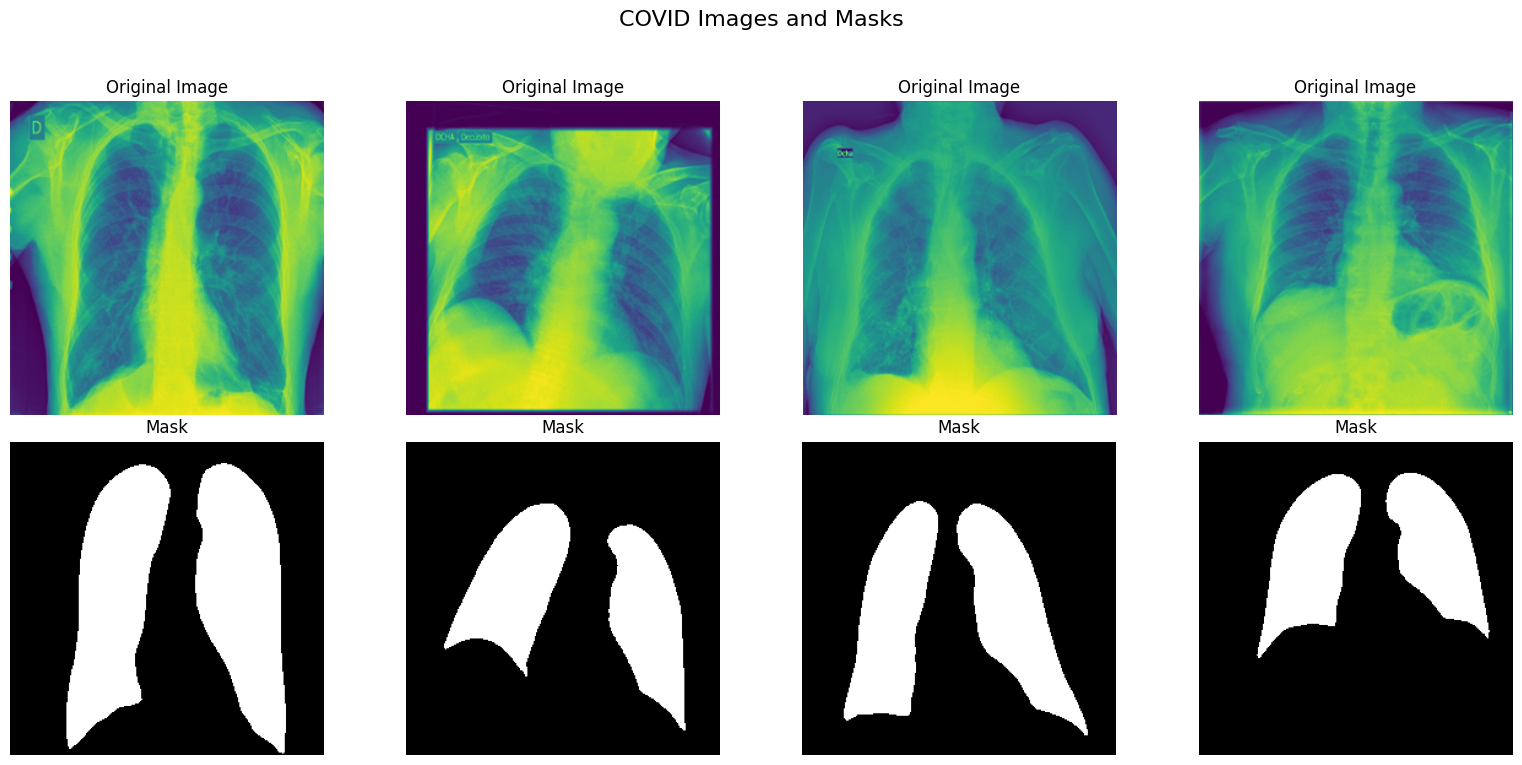


Displaying samples for category: Normal


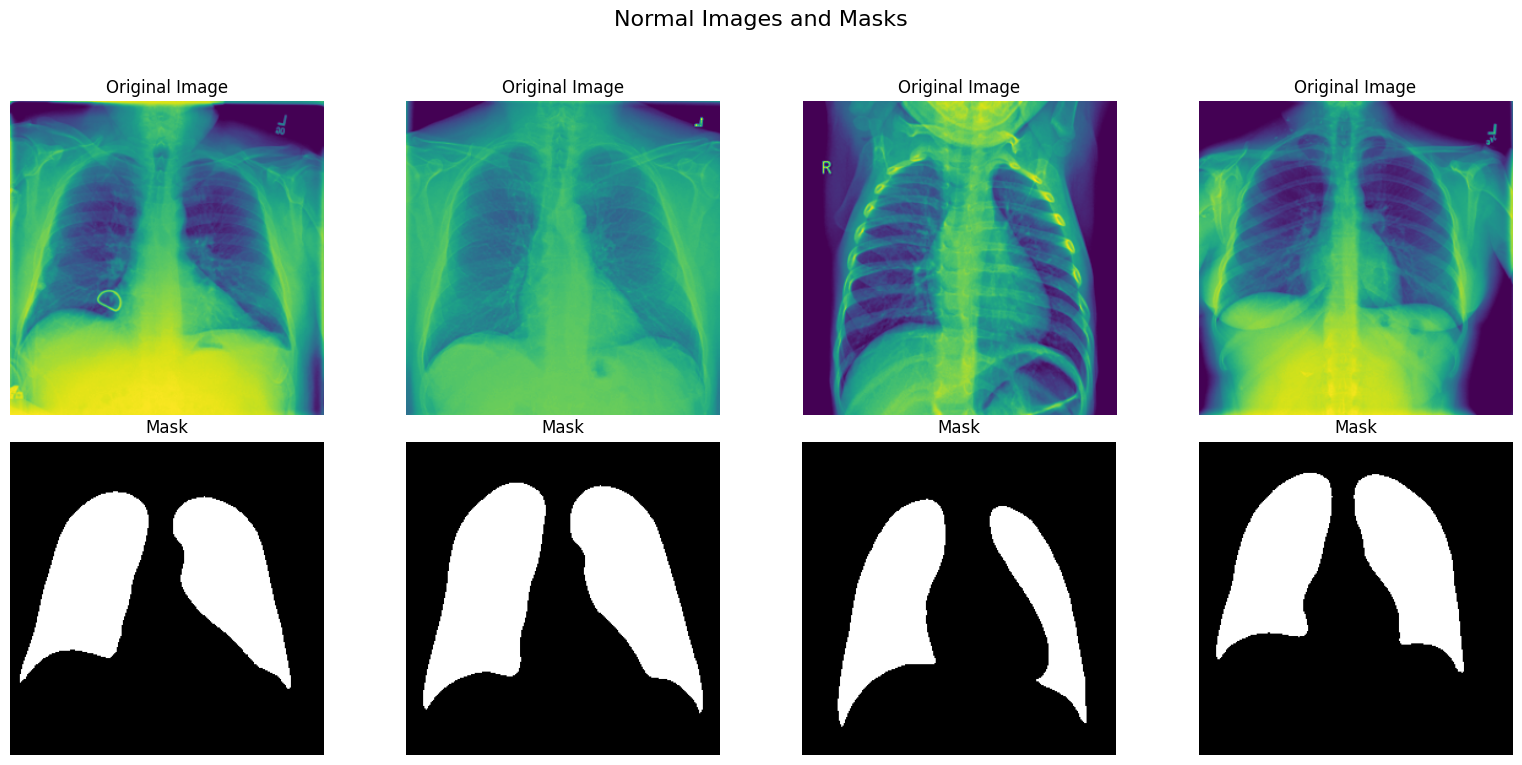


Displaying samples for category: Lung_Opacity


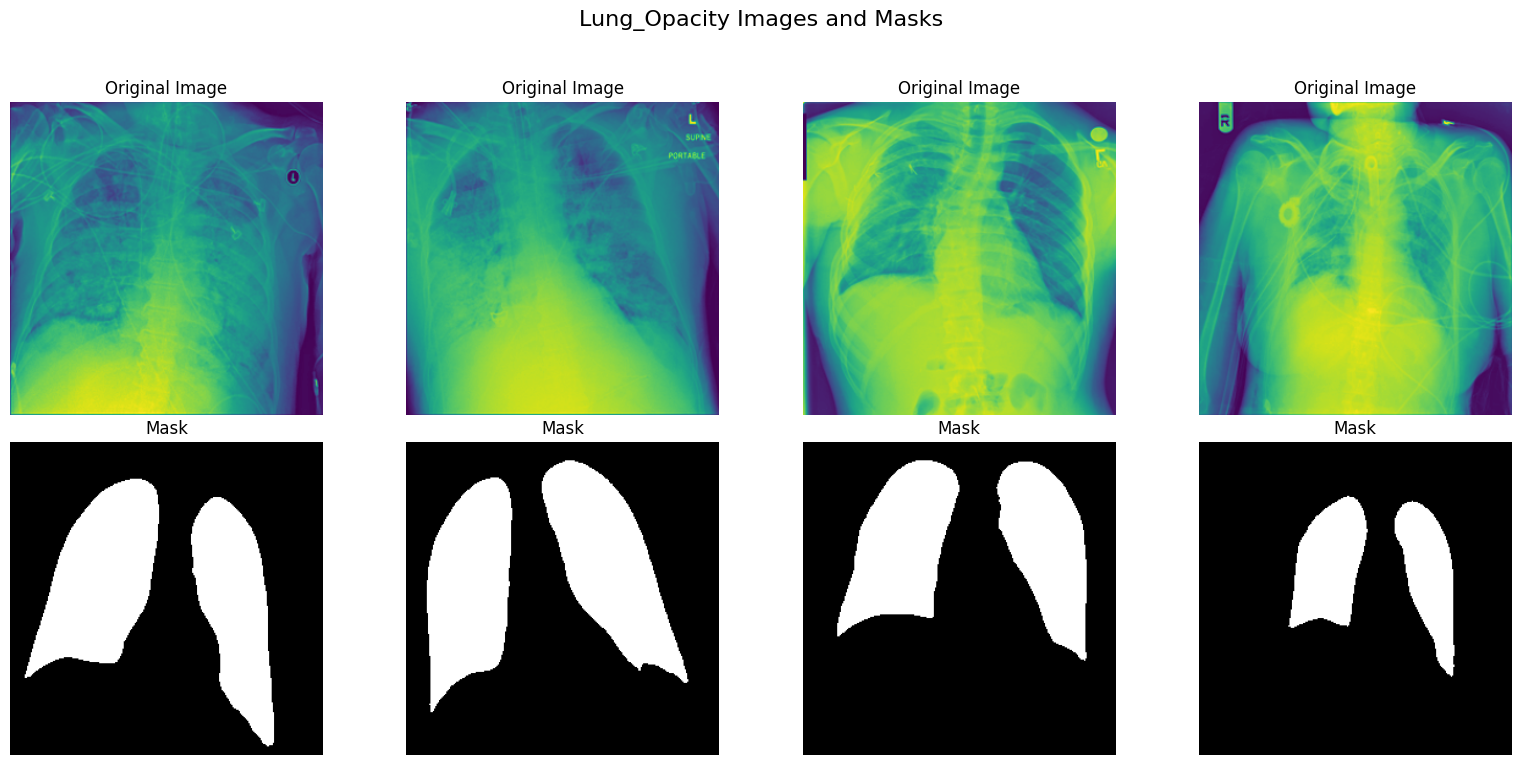


Displaying samples for category: Viral Pneumonia


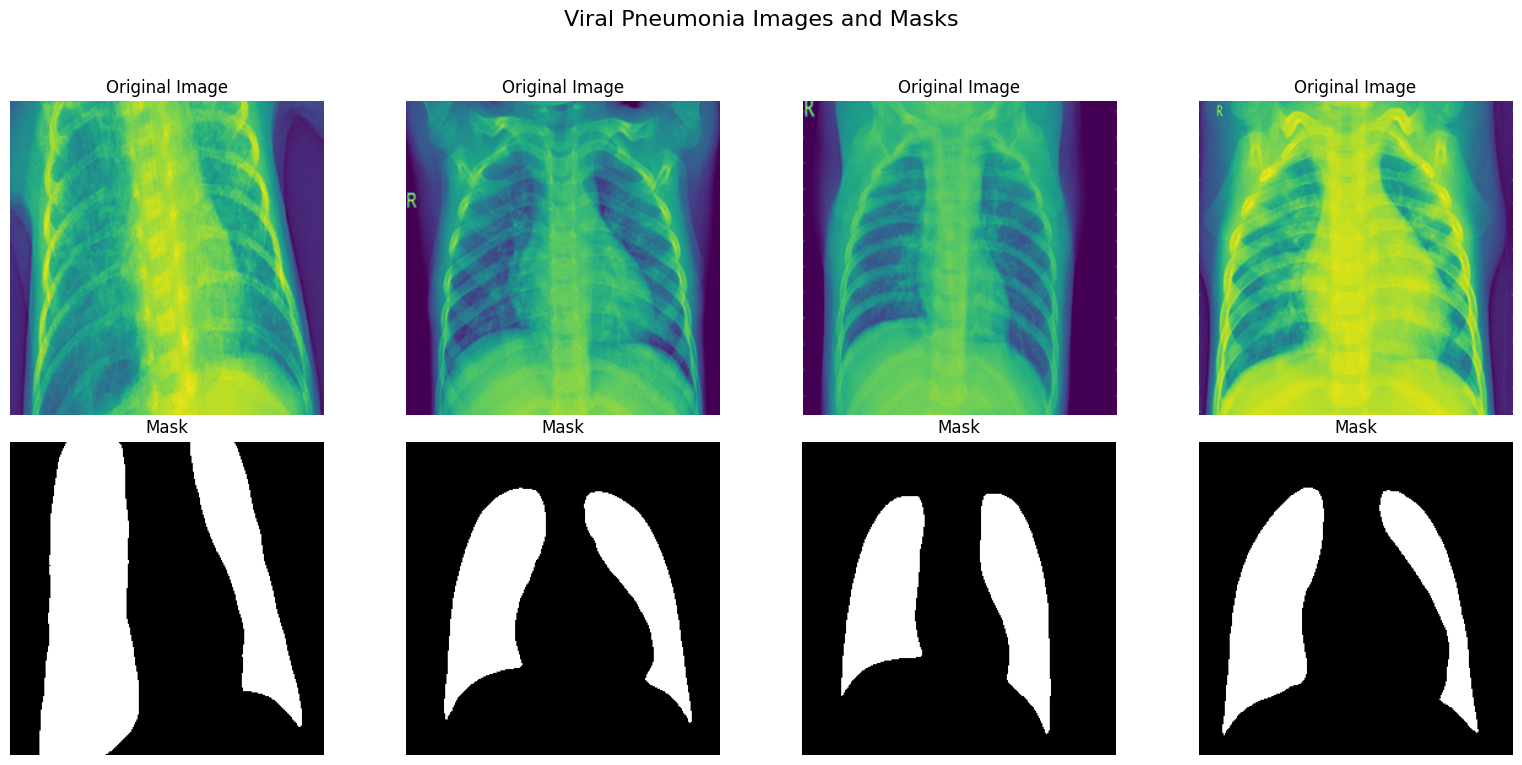

In [ ]:
import random
import matplotlib.pyplot as plt
import cv2
import os

# On suppose que 'CATEGORIES' et 'image_paths' ont déjà été définis aux étapes précédentes
# CATEGORIES = ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
# image_paths = { ... dictionnaire rempli ... }

# Boucle sur chaque catégorie pour afficher des exemples d'images et de masques
for category in CATEGORIES:
    print(f"\nDisplaying samples for category: {category}")

    # Récupérer les répertoires des images et des masques pour la catégorie courante
    current_image_dir = image_paths[f'{category}_images']
    current_mask_dir = image_paths[f'{category}_masks']

    # Obtenir la liste de tous les fichiers image dans la catégorie courante
    all_image_files = [
        f for f in os.listdir(current_image_dir)
        if f.endswith(('.png', '.jpg', '.jpeg'))
    ]

    # Sélectionner aléatoirement 4 fichiers image
    # S'assurer de ne pas sélectionner plus de fichiers qu'il n'en existe
    num_samples = min(4, len(all_image_files))
    selected_image_files = random.sample(all_image_files, num_samples)

    # Créer une figure avec une grille 2 x num_samples de sous-graphiques
    fig = plt.figure(figsize=(4 * num_samples, 8))
    fig.suptitle(f'{category} Images and Masks', fontsize=16)

    # # Si aucune image n'est trouvée pour cette catégorie, on peut ignorer l'affichage
    # if num_samples == 0:
    #     print(f"Aucune image trouvée pour la catégorie {category}.")
    #     plt.close(fig)
    #     continue

    for i, img_filename in enumerate(selected_image_files):
        # Construire les chemins complets pour l'image et le masque
        image_path = os.path.join(current_image_dir, img_filename)
        mask_path = os.path.join(current_mask_dir, img_filename)  # On suppose que le masque porte le même nom de fichier

        # Charger l'image
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        # Charger le masque (s'il existe)
        mask = None
        if os.path.exists(mask_path):
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        else:
            print(f"Warning: Mask not found for {img_filename} in {category}.")

        # Afficher l'image originale sur la première ligne
        plt.subplot(2, num_samples, i + 1)
        plt.imshow(img)
        plt.title('Original Image')
        plt.axis('off')

        # Afficher le masque sur la deuxième ligne
        plt.subplot(2, num_samples, num_samples + i + 1)
        if mask is not None:
            # Les masques sont généralement en niveaux de gris
            plt.imshow(mask, cmap='gray')
            plt.title('Mask')
        else:
            # Afficher un texte si le masque est indisponible
            plt.text(
                0.5, 0.5, 'Mask N/A',
                horizontalalignment='center',
                verticalalignment='center',
                transform=plt.transAxes,
                fontsize=12,
                color='red'
            )
        plt.axis('off')

    # Ajuster la mise en page pour laisser de la place au titre principal
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

#  Prétraitement des images et préparation des données
Prétraitez les images radiographiques en chargeant les images et leurs masques en niveaux de gris, en appliquant les masques pour isoler la région d'intérêt, en redimensionnant les radiographies et masques à **128×128** pour limiter l'usage mémoire, puis en appliquant l'amélioration du contraste CLAHE. Aplatissez chaque image traitée en un vecteur de caractéristiques 1D et associez-le à son étiquette de catégorie. Réalisez ensuite une classification **boosting** multiclasses avec **PCA à 200 composantes** et conservez les mêmes sorties d'évaluation (CV, rapport de classification, matrice de confusion, courbe train/validation du boosting).

Charger toutes les images et leurs masques en niveaux de gris, appliquer les masques pour isoler la région d'intérêt, **redimensionner les radiographies à 128×128** pour rester compatible avec la RAM Colab, appliquer l'amélioration du contraste CLAHE, puis aplatir chaque image traitée en un vecteur de caractéristiques 1D et l'associer à son étiquette de catégorie.

In [ ]:
# =======================================================================================================================
# La première étape consiste à initialiser les listes destinées aux features et aux labels, puis à créer l’objet CLAHE. 
# Cela permet de préparer les composants nécessaires avant de parcourir les images pour effectuer leur prétraitement. 
# =======================================================================================================================

features_list = []
labels_list = []

# Créer l'objet CLAHE
clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT, tileGridSize=CLAHE_TILE_SIZE)

print("✅ Listes initialisées et objet CLAHE créé.")

✅ Listes initialisées et objet CLAHE créé.


In [ ]:
#======================================================================================================================================
#  cette étape consiste à parcourir chaque catégorie, 
# à charger les images et les masques, 
# à appliquer le masquage, 
# à redimensionner les images, 
# à appliquer CLAHE si APPLY_CLAHE vaut True, 
# puis à aplatir chaque image. 
# 
# Le vecteur de features obtenu ainsi que le label correspondant sont ensuite ajoutés aux listes initialisées précédemment.
#======================================================================================================================================

observed_shapes = []
skipped_unexpected_shape = 0

for category in CATEGORIES:
    current_image_dir = image_paths[f'{category}_images']
    current_mask_dir = image_paths[f'{category}_masks']

    print(f"Processing {category}...")
    for img_filename in os.listdir(current_image_dir):
        if img_filename.endswith(('.png', '.jpg', '.jpeg')):
            image_path = os.path.join(current_image_dir, img_filename)
            mask_path = os.path.join(current_mask_dir, img_filename)

            img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

            if img is None or mask is None:
                print(f"Warning: Could not load image or mask for {img_filename} in {category}. Skipping.")
                continue

            observed_shapes.append(img.shape)

            # Si les tailles diffèrent, on aligne d'abord le masque sur l'image
            if img.shape != mask.shape:
                mask = cv2.resize(mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)

            # Resize mémoire-friendly demandé : 128x128
            if RESIZE_IMAGES:
                img = cv2.resize(img, (TARGET_SIZE, TARGET_SIZE), interpolation=cv2.INTER_AREA)
                mask = cv2.resize(mask, (TARGET_SIZE, TARGET_SIZE), interpolation=cv2.INTER_NEAREST)

            _, binary_mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
            masked_img = cv2.bitwise_and(img, img, mask=binary_mask)

            if APPLY_CLAHE:
                processed_img = clahe.apply(masked_img)
            else:
                processed_img = masked_img

            # float32 pour limiter la RAM
            features_list.append(processed_img.astype(np.float32).flatten())
            labels_list.append(category)

print("✅ Toutes les images ont été traitées.")
print(f"Nombre total de caractéristiques extraites: {len(features_list)}")
print(f"Nombre total d'étiquettes: {len(labels_list)}")
print(f"Formes observées (uniques): {sorted(set(observed_shapes))[:10]}")
print(f"Images ignorées pour forme inattendue: {skipped_unexpected_shape}")
print(f"Taille finale des images utilisées pour le modèle: {TARGET_SIZE}x{TARGET_SIZE}")


Processing COVID...
Processing Normal...
Processing Lung_Opacity...
Processing Viral Pneumonia...
✅ Toutes les images ont été traitées.
Nombre total de caractéristiques extraites: 21165
Nombre total d'étiquettes: 21165
Formes observées (uniques): [(299, 299)]
Images ignorées pour forme inattendue: 0
Taille finale des images utilisées pour le modèle: 128x128


In [ ]:
#=======================================================================================================================
# L’étape précédente a permis de prétraiter correctement les images et d’extraire les caractéristiques dans des listes.
# Cette étape consiste à convertir ces listes en tableaux NumPy afin de faciliter le traitement 
# et d’assurer leur compatibilité avec scikit-learn. 
# Il faut ensuite encoder les étiquettes catégorielles, initialement sous forme de chaînes de caractères, en valeurs numériques, 
# car ce format est requis par les modèles de machine learning.
#=======================================================================================================================

from sklearn.preprocessing import LabelEncoder

# Convertir les listes en tableaux NumPy
X = np.array(features_list, dtype=np.float32)
y_str = np.array(labels_list)

# Encoder les étiquettes de catégorie (chaînes de caractères) en valeurs numériques
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_str)

print(f"✅ Données converties en tableaux NumPy: X.shape={X.shape}, y.shape={y.shape}")
print(f"✅ Étiquettes encodées: {label_encoder.classes_}")
print(f"✅ Type mémoire de X: {X.dtype}")
print(f"✅ Taille approximative de X en RAM: {X.nbytes / (1024**3):.2f} GB")


✅ Données converties en tableaux NumPy: X.shape=(21165, 16384), y.shape=(21165,)
✅ Étiquettes encodées: ['COVID' 'Lung_Opacity' 'Normal' 'Viral Pneumonia']
✅ Type mémoire de X: float32
✅ Taille approximative de X en RAM: 1.29 GB


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Modèle Boosting : PCA(200) + HistGradientBoostingClassifier

Cette version reprend les apprentissages des notebooks précédents : **resize 128×128**, **masques**, **CLAHE**, **PCA à 200 composantes** et **gestion du déséquilibre** via des `sample_weight` équilibrés. On utilise ici `HistGradientBoostingClassifier`, plus adapté qu'un SVC RBF lorsque la RAM CPU est limitée.

✅ Pipeline Boosting configuré
📌 PCA n_components = 200
📌 Paramètres boosting = {'loss': 'log_loss', 'learning_rate': 0.05, 'max_iter': 300, 'max_leaf_nodes': 31, 'min_samples_leaf': 20, 'l2_regularization': 0.0, 'early_stopping': True, 'validation_fraction': 0.1, 'n_iter_no_change': 20, 'scoring': 'f1_macro', 'random_state': 42}
📌 Validation croisée = StratifiedKFold(n_splits=3, random_state=42, shuffle=True)
Fold 1 | train_macro_f1=0.2471 | val_macro_f1=0.6456 | fit_time=45.34s
Fold 2 | train_macro_f1=0.1658 | val_macro_f1=0.6682 | fit_time=52.81s
Fold 3 | train_macro_f1=0.1618 | val_macro_f1=0.6542 | fit_time=44.58s

✅ Résultats CV=3
Train macro-F1 moyen : 0.1916 ± 0.0393
Val   macro-F1 moyen : 0.6560 ± 0.0093
Temps moyen par fold : 47.58 s


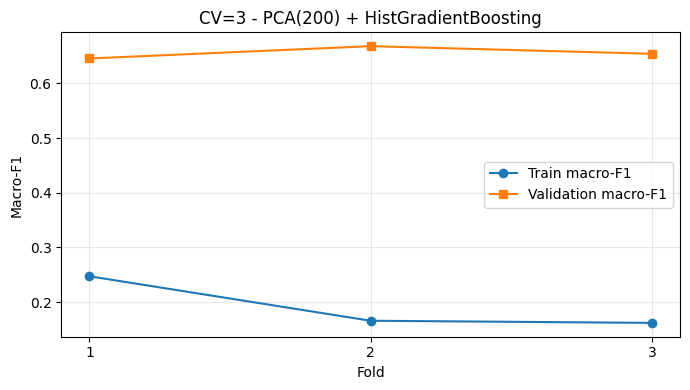


⏳ Début de l'entraînement final du modèle boosting...
✅ Entraînement final terminé en 66.68 secondes.


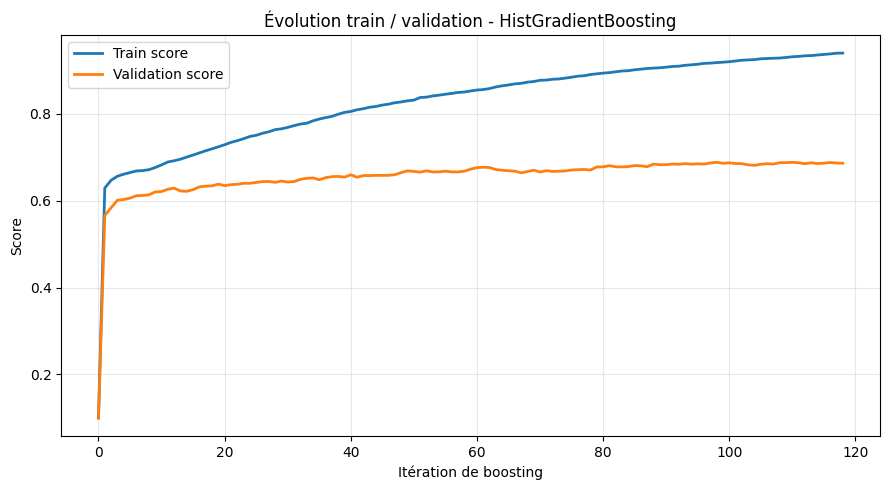

✅ Nombre d'itérations réellement utilisées : 118
✅ Prédictions effectuées sur l'ensemble de test.

--- Rapport de Classification ---
                 precision    recall  f1-score   support

          COVID       0.48      0.44      0.46       723
   Lung_Opacity       0.67      0.69      0.68      1203
         Normal       0.80      0.79      0.80      2038
Viral Pneumonia       0.80      0.86      0.83       269

       accuracy                           0.71      4233
      macro avg       0.69      0.70      0.69      4233
   weighted avg       0.71      0.71      0.71      4233


--- Matrice de Confusion ---


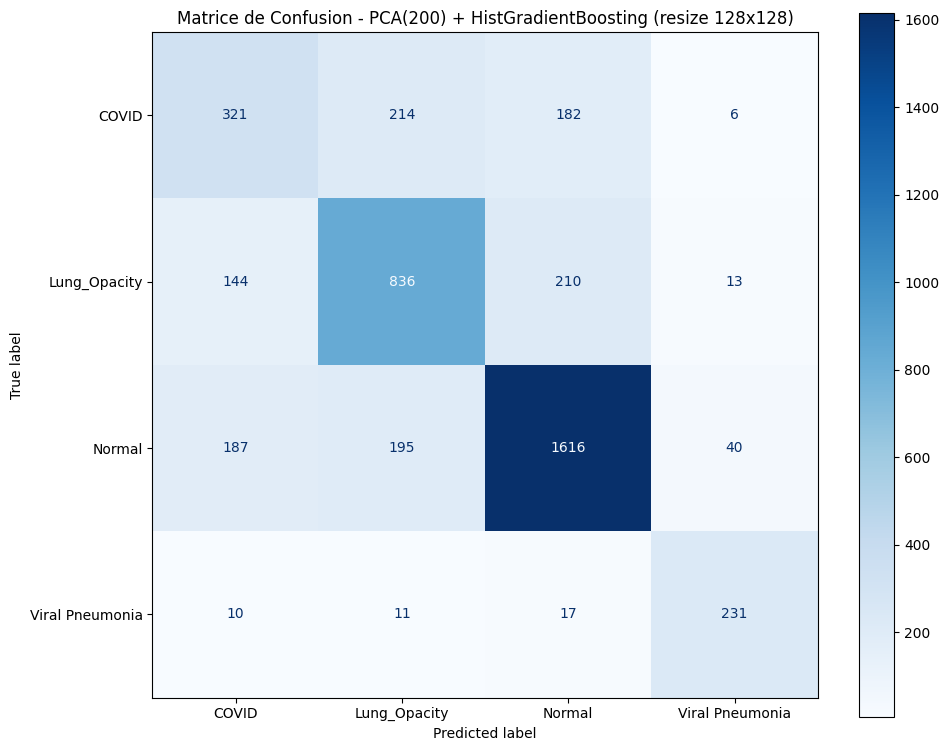

In [ ]:

from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight
import time

# ==================================================
# PCA + HistGradientBoostingClassifier (Boosting)
# ==================================================
# On garde l'expérience la plus utile des notebooks précédents :
# - resize 128x128 pour limiter la RAM
# - masquage + CLAHE
# - PCA fixé à 200 composantes
# - évaluation multiclasses avec macro-F1
#
# Remarque :
# On ne met pas StandardScaler ici pour économiser de la RAM.
# Les pixels sont déjà normalisés dans [0, 1], et l'objectif est de
# conserver un pipeline plus léger pour Colab.

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

boost_params = {
    "loss": "log_loss",
    "learning_rate": 0.05,
    "max_iter": 300,
    "max_leaf_nodes": 31,
    "min_samples_leaf": 20,
    "l2_regularization": 0.0,
    "early_stopping": True,
    "validation_fraction": 0.1,
    "n_iter_no_change": 20,
    "scoring": "f1_macro",
    "random_state": SEED,
}

print("✅ Pipeline Boosting configuré")
print("📌 PCA n_components = 200")
print("📌 Paramètres boosting =", boost_params)
print("📌 Validation croisée =", cv)

# --------------------------------------------------
# 1) Validation croisée manuelle (CV=3)
# --------------------------------------------------
cv_train_scores = []
cv_val_scores = []
cv_fit_times = []

for fold, (tr_idx, val_idx) in enumerate(cv.split(X_train, y_train), start=1):
    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    sw_tr = compute_sample_weight(class_weight="balanced", y=y_tr)

    pipe_pca_boost_cv = Pipeline([
        ("pca", PCA(n_components=200, svd_solver="randomized", copy=False, random_state=SEED)),
        ("boost", HistGradientBoostingClassifier(**boost_params))
    ])

    t0 = time.time()
    pipe_pca_boost_cv.fit(X_tr, y_tr, boost__sample_weight=sw_tr)
    fit_time = time.time() - t0

    y_tr_pred = pipe_pca_boost_cv.predict(X_tr)
    y_val_pred = pipe_pca_boost_cv.predict(X_val)

    train_f1 = f1_score(y_tr, y_tr_pred, average="macro")
    val_f1 = f1_score(y_val, y_val_pred, average="macro")

    cv_train_scores.append(train_f1)
    cv_val_scores.append(val_f1)
    cv_fit_times.append(fit_time)

    print(f"Fold {fold} | train_macro_f1={train_f1:.4f} | val_macro_f1={val_f1:.4f} | fit_time={fit_time:.2f}s")

print("\n✅ Résultats CV=3")
print(f"Train macro-F1 moyen : {np.mean(cv_train_scores):.4f} ± {np.std(cv_train_scores):.4f}")
print(f"Val   macro-F1 moyen : {np.mean(cv_val_scores):.4f} ± {np.std(cv_val_scores):.4f}")
print(f"Temps moyen par fold : {np.mean(cv_fit_times):.2f} s")

# Petit récap visuel CV
plt.figure(figsize=(7, 4))
fold_ids = np.arange(1, len(cv_train_scores) + 1)
plt.plot(fold_ids, cv_train_scores, marker='o', label='Train macro-F1')
plt.plot(fold_ids, cv_val_scores, marker='s', label='Validation macro-F1')
plt.xticks(fold_ids)
plt.xlabel("Fold")
plt.ylabel("Macro-F1")
plt.title("CV=3 - PCA(200) + HistGradientBoosting")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 2) Entraînement final sur tout le train
# --------------------------------------------------
sw_train = compute_sample_weight(class_weight="balanced", y=y_train)

pipe_pca_boost = Pipeline([
    ("pca", PCA(n_components=200, svd_solver="randomized", copy=False, random_state=SEED)),
    ("boost", HistGradientBoostingClassifier(**boost_params))
])

print("\n⏳ Début de l'entraînement final du modèle boosting...")
start_time = time.time()
pipe_pca_boost.fit(X_train, y_train, boost__sample_weight=sw_train)
training_time = time.time() - start_time
print(f"✅ Entraînement final terminé en {training_time:.2f} secondes.")

# --------------------------------------------------
# 3) Évolution train / validation pendant le boosting
# --------------------------------------------------
boost_model = pipe_pca_boost.named_steps["boost"]

if hasattr(boost_model, "train_score_") and len(boost_model.train_score_) > 0:
    iters = np.arange(len(boost_model.train_score_))

    plt.figure(figsize=(9, 5))
    plt.plot(iters, boost_model.train_score_, label="Train score", linewidth=2)

    if hasattr(boost_model, "validation_score_") and len(boost_model.validation_score_) > 0:
        plt.plot(iters, boost_model.validation_score_, label="Validation score", linewidth=2)

    plt.xlabel("Itération de boosting")
    plt.ylabel("Score")
    plt.title("Évolution train / validation - HistGradientBoosting")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"✅ Nombre d'itérations réellement utilisées : {boost_model.n_iter_}")
else:
    print("ℹ️ Pas de courbe train/validation disponible (early_stopping désactivé ou version sklearn différente).")

# --------------------------------------------------
# 4) Prédictions et sorties de classification
# --------------------------------------------------
y_pred = pipe_pca_boost.predict(X_test)
print("✅ Prédictions effectuées sur l'ensemble de test.")

print("\n--- Rapport de Classification ---")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_test, y_pred)

print("\n--- Matrice de Confusion ---")
fig, ax = plt.subplots(figsize=(10, 8))
cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
cmd.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')
ax.set_title('Matrice de Confusion - PCA(200) + HistGradientBoosting (resize 128x128)')
plt.tight_layout()
plt.show()
